# Milestone 2 – Building Your Evolutionary Algorithm



In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle

from src.ea import (
    toolbox, run_evolution, diversity, build_stats,
    mutate_random_flip, mutate_block, mutate_grow_shrink,
    cx_uniform_voxel, cx_one_point_slice
)
from src.representation import random_genome, largest_connected_component
from src.fitness import evaluate_genome
from src.diagnostics import (
    plot_fitness_curve, plot_diversity_curve,
    plot_fitness_landscape, plot_material_heatmap,
    plot_multi_fitness_curves
)

os.makedirs('../results', exist_ok=True)


## 5.2.1 – Verify DEAP Toolbox Setup

In [3]:
from deap import creator, tools

# Test individual creation
ind = toolbox.individual()
print('Individual shape:', ind.shape)
print('Individual dtype:', ind.dtype)
print('Individual type:', type(ind).__name__)

# Test population
pop = toolbox.population(n=10)
print(f'Population size: {len(pop)}')

# Test evaluation
f = toolbox.evaluate(ind)
print(f'Fitness tuple: {f}')

Individual shape: (8, 8, 8)
Individual dtype: int32
Individual type: Individual
Population size: 10
Fitness tuple: (0.4850037357422378,)


##  Mutation Operators

In [16]:
np.random.seed(0)
#checking does the mutation functions actually change the genome correctly?
# Test mutate_random_flip
ind = toolbox.individual() #Creates one genome
before = ind.copy() #Stores original body before mutation.
result, = mutate_random_flip(ind, flip_prob=0.05) #each voxel has 5% chance of changing material
changed = (before != result).sum() #how many voxel positions changed.
print(f'mutate_random_flip: {changed} ')

# Test mutate_block
ind2 = toolbox.individual()
before2 = ind2.copy()
result2, = mutate_block(ind2, block_size=2) #a small cube region
changed2 = (before2 != result2).sum()
print(f'mutate_block: {changed2} ')

# adding or removing one voxel, 0 means no change 1 means change
ind3 = toolbox.individual()
before3 = ind3.copy()
result3, = mutate_grow_shrink(ind3)
changed3 = (before3 != result3).sum()
print(f'mutate_grow_shrink: {changed3} ')

print('\nAll mutation operators OK')

mutate_random_flip: 16 
mutate_block: 5 
mutate_grow_shrink: 0 

All mutation operators OK


##  Crossover 

In [21]:
np.random.seed(1)

p1 = toolbox.individual()
p2 = toolbox.individual()

# Keep copies only for comparison, not for crossover
p1_orig = np.array(p1)
p2_orig = np.array(p2)

# DEAP crossover: pass original DEAP individuals
c1, c2 = cx_uniform_voxel(p1, p2, indpb=0.5)

swapped = ((c1 != p1_orig) & (c1 == p2_orig)).sum()
print(f'cx_uniform_voxel: {swapped} voxels swapped ')

# DEAP one-point crossover
p3 = toolbox.individual()
p4 = toolbox.individual()

c3, c4 = cx_one_point_slice(p3, p4)

print(f'cx_one_point_slice: child shapes {c3.shape}, {c4.shape}')



cx_uniform_voxel: 148 voxels swapped 
cx_one_point_slice: child shapes (8, 8, 8), (8, 8, 8)


## 5.2.2 – Run Baseline Evolution

In [6]:
print('Running baseline evolution (200 generations)...')
print('This may take several minutes with the heuristic backend.\n')

np.random.seed(42)
pop, logbook, hof = run_evolution(
    pop_size=50, #Initial population
    n_gen=200, #Evolution repeats for 200 generations
    mu=50, #keep 50 surviving robots
    lambda_=100, #Each generation creates 100 offspring
    cxpb=0.5, #50% probability offspring created via:crossover
    mutpb=0.3, #30% probability offspring created via:mutation
    results_dir='../results',
    run_tag='baseline',
    verbose=True
)

print(f'\nBest fitness: {hof[0].fitness.values[0]:.4f}')

Running baseline evolution (200 generations)...
This may take several minutes with the heuristic backend.

diversity	gen	max     	mean  	nevals	std      
0.58604  	0  	0.519984	0.4665	50    	0.0348954
0.570738 	1  	0.532847	0.502592	78    	0.0168921
0.549563 	2  	0.540319	0.513693	82    	0.0120794
0.499627 	3  	0.540319	0.523361	85    	0.00823296
0.446566 	4  	0.537392	0.526669	82    	0.00730469
0.339582 	5  	0.547583	0.531834	82    	0.00690552
0.188643 	6  	0.547583	0.536127	83    	0.00513934
0.209349 	7  	0.549544	0.539265	77    	0.00629437
0.164208 	8  	0.549544	0.541653	80    	0.00644118
0.0941948	9  	0.555027	0.545417	85    	0.00552626
0.102157 	10 	0.561932	0.54743 	76    	0.00493764
0.0753763	11 	0.560978	0.547994	78    	0.00483118
0.0604257	12 	0.560978	0.549424	70    	0.00340261
0.0650542	13 	0.560978	0.550659	75    	0.00470518
0.0678571	14 	0.565567	0.550443	82    	0.00592731
0.0706872	15 	0.571082	0.551076	84    	0.00479777
0.0749952	16 	0.568072	0.553142	79    	0.00591089
0

## 5.2.3 – Diagnostic Visualisations

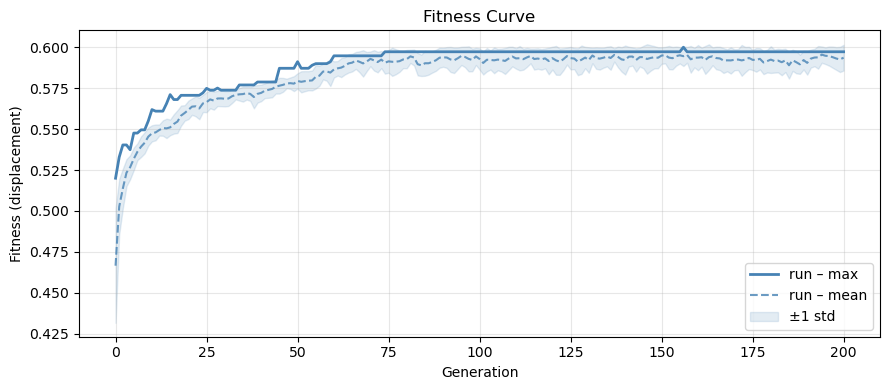

 from the plot i can understand that after around 50–70 generations, the improvement becomes slower and starts stabilizing.The maximum fitness reaches close to 0.60, showing the best solution found by the model.


In [24]:
# Plot 9: Fitness curve
fig = plot_fitness_curve(logbook, save_path='../results/baseline_fitness.png')
plt.show()
print(" from the plot i can understand that after around 50–70 generations, the improvement becomes slower and starts stabilizing.The maximum fitness reaches close to 0.60, showing the best solution found by the model.")

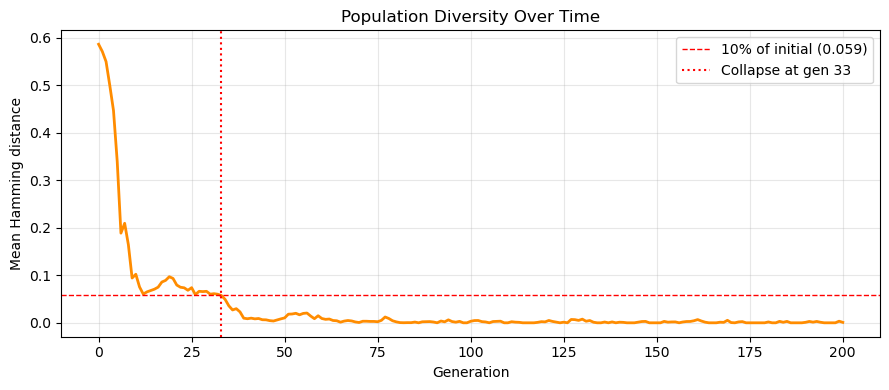

Diversity collapsed at generation 33


In [23]:
# Plot 10: Diversity curve
fig, collapse_gen = plot_diversity_curve(logbook, save_path='../results/baseline_diversity.png')
plt.show()
if collapse_gen:
    print(f'Diversity collapsed at generation {collapse_gen}')
else:
    print('Diversity did not drop below 10% threshold good exploration!')

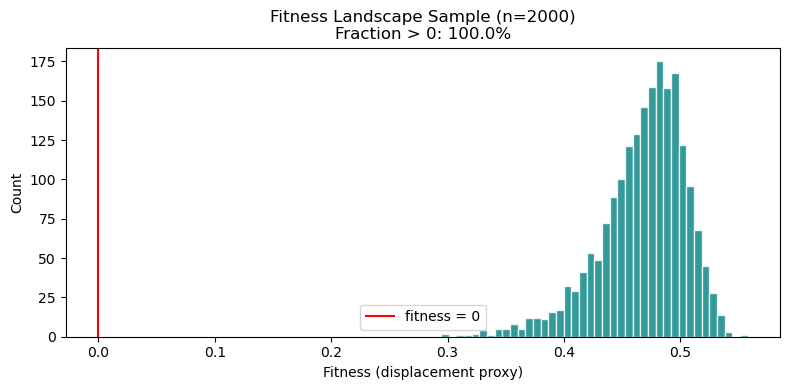

The peak around 0.48–0.50 shows this is the most common fitness range.The red line at fitness = 0 shows that no sampled solutions had zero or negative fitness.


In [25]:
# Plot 11: Fitness landscape sample
fig, frac_pos = plot_fitness_landscape(
    evaluate_genome, n_samples=2000,
    save_path='../results/fitness_landscape.png'
)
plt.show()
print('The peak around 0.48–0.50 shows this is the most common fitness range.The red line at fitness = 0 shows that no sampled solutions had zero or negative fitness.')

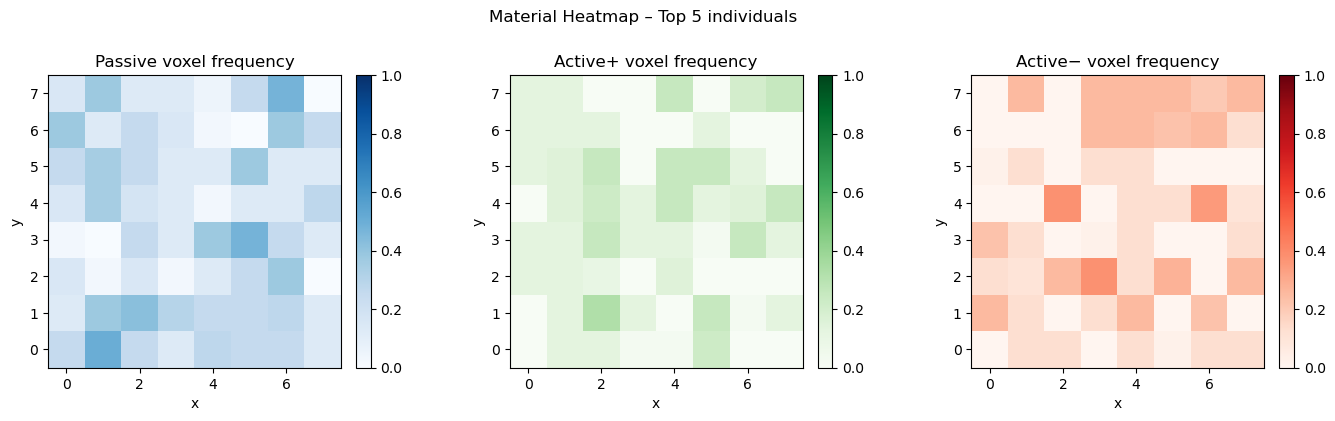

This heatmap shows where different voxel materials appear most often in the top 10 evolved robots.
passive voxel - They appear pretty consistently across the whole robot, especially in the top-left and top-right corners
active+ -Concentrated mostly in the middle and right side of the robot.not too much in left
active- -Spread more towards the middle


In [31]:
# Plot 12: Material heatmap
fig = plot_material_heatmap(hof, top_n=10, save_path='../results/material_heatmap.png')
plt.show()
print('This heatmap shows where different voxel materials appear most often in the top 10 evolved robots.')
print('passive voxel - They appear pretty consistently across the whole robot, especially in the top-left and top-right corners')
print('active+ -Concentrated mostly in the middle and right side of the robot.not too much in left')
print('active- -Spread more towards the middle')

## 5.2.4 – Operator Comparison Experiment

In [33]:
from src.ea import mutate_random_flip, mutate_block, mutate_grow_shrink

operators = [
    ('random_flip',  mutate_random_flip),
    ('block',        mutate_block),
    ('grow_shrink',  mutate_grow_shrink),
]

operator_logbooks = []
N_SEEDS = 3
gens_to_check = [50, 100, 150, 200]

for op_name, op_fn in operators:
    seed_logbooks = []

    for seed in range(N_SEEDS):
        np.random.seed(seed * 100)

        toolbox.unregister('mutate')
        toolbox.register('mutate', op_fn)

        _, lb, _ = run_evolution(
            pop_size=50,
            n_gen=200,
            mu=50,
            lambda_=100,
            cxpb=0.5,
            mutpb=0.3,
            results_dir='../results',
            run_tag=f'{op_name}_seed{seed}',
            verbose=False
        )

        seed_logbooks.append(lb)

        print(f'\n{op_name} | seed {seed}')
        for g in gens_to_check:
            best_fit = lb.select("max")[g]
            print(f'Generation {g}: best fitness = {best_fit:.4f}')

    operator_logbooks.append((op_name, seed_logbooks))

# Reset to default mutation operator
toolbox.unregister('mutate')
toolbox.register('mutate', mutate_random_flip)




Best fitness: 0.5949
Logs saved to ../results/

random_flip | seed 0
Generation 50: best fitness = 0.5892
Generation 100: best fitness = 0.5924
Generation 150: best fitness = 0.5959
Generation 200: best fitness = 0.5959

Best fitness: 0.6135
Logs saved to ../results/

random_flip | seed 1
Generation 50: best fitness = 0.6024
Generation 100: best fitness = 0.6072
Generation 150: best fitness = 0.6072
Generation 200: best fitness = 0.6135

Best fitness: 0.6608
Logs saved to ../results/

random_flip | seed 2
Generation 50: best fitness = 0.6532
Generation 100: best fitness = 0.6608
Generation 150: best fitness = 0.6608
Generation 200: best fitness = 0.6611

Best fitness: 0.6468
Logs saved to ../results/

block | seed 0
Generation 50: best fitness = 0.6137
Generation 100: best fitness = 0.6468
Generation 150: best fitness = 0.6468
Generation 200: best fitness = 0.6471

Best fitness: 0.6603
Logs saved to ../results/

block | seed 1
Generation 50: best fitness = 0.6297
Generation 100: best 

In [12]:
# Plot fitness at checkpoints
checkpoints = [50, 100, 150, 200]

print('Best fitness at checkpoints:')
print(f'{"Operator":<15} ' + ' '.join(f'Gen{g:<6}' for g in checkpoints))
print('-' * 45)

for op_name, seed_lbs in operator_logbooks:
    row = f'{op_name:<15}'
    for ck in checkpoints:
        vals = [lb.select('max')[ck-1] for lb in seed_lbs]
        row += f' {np.mean(vals):.3f}   '
    print(row)

Best fitness at checkpoints:
Operator        Gen50     Gen100    Gen150    Gen200   
---------------------------------------------
random_flip     0.642    0.659    0.660    0.664   
block           0.617    0.630    0.630    0.630   
grow_shrink     0.615    0.617    0.618    0.619   


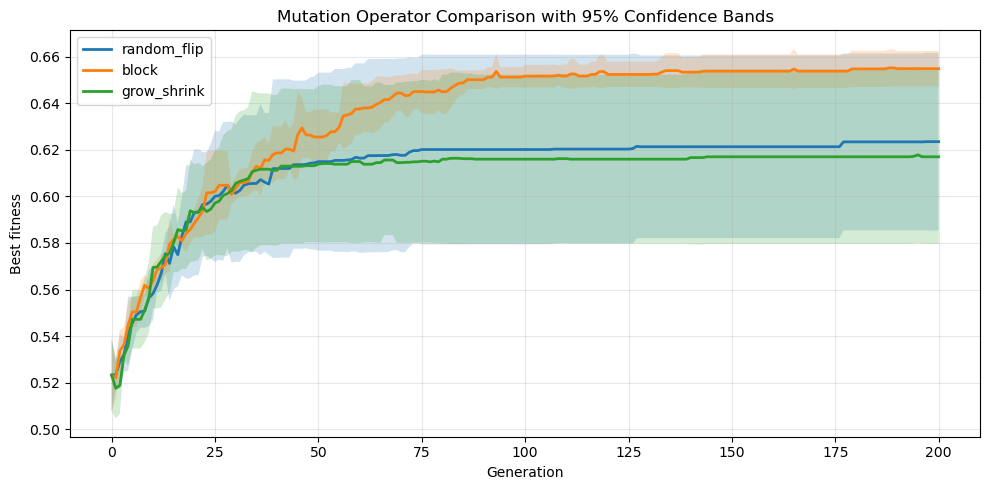

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Plot fitness curves with 95% confidence bands
fig, ax = plt.subplots(figsize=(10, 5))

for op_name, seed_logbooks in operator_logbooks:
    # Shape: (n_seeds, n_generations)
    max_curves = np.array([
        lb.select("max") for lb in seed_logbooks
    ])

    gens = np.array(seed_logbooks[0].select("gen"))

    mean_curve = max_curves.mean(axis=0)
    std_curve = max_curves.std(axis=0, ddof=1)

    n = max_curves.shape[0]
    ci95 = 1.96 * std_curve / np.sqrt(n)

    ax.plot(gens, mean_curve, label=op_name, linewidth=2)
    ax.fill_between(
        gens,
        mean_curve - ci95,
        mean_curve + ci95,
        alpha=0.2
    )

ax.set_xlabel("Generation")
ax.set_ylabel("Best fitness")
ax.set_title("Mutation Operator Comparison with 95% Confidence Bands")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/operator_comparison_95ci.png", dpi=150, bbox_inches="tight")
plt.show()

## Q16 – Operator Analysis (200 words)

**Which operator performed best and why?**

Block mutation performed the best in this experiment because it achieved the highest average fitness, reaching around **0.655** by generation 200. The fitness graph showed that block mutation started outperforming the other operators quite early, around generations 25–50, and continued improving steadily throughout the evolutionary run. This suggests that changing an entire block of voxels helped the evolutionary algorithm explore new robot body shapes more effectively while still preserving useful structures from previous generations.

This result can be understood using the ideas of exploration and exploitation. Exploration means searching for very different solutions and discovering new morphologies, while exploitation means making small improvements to solutions that are already performing well. Random flip mutation mainly focuses on exploitation because it changes only a few voxels at a time. These small local modifications help refine existing robots, but they are not very effective for discovering completely new body structures. As a result, the population often becomes trapped near local optima, and fitness improvement slows down over time.

Grow-shrink mutation was more exploratory because it changes the robot’s body topology by adding or removing voxels from the surface. However, the confidence bands in the graph were much wider, showing that the results varied greatly between runs. Some runs discovered strong solutions, while others stagnated early, making the operator less reliable. Block mutation achieved the best balance between exploration and exploitation. Its medium-sized structural changes allowed the search process to discover new morphologies while still preserving enough useful information from successful parents, leading to both higher fitness and more stable performance across different random seeds.

